# Figure 5

In [28]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import os
import pandas as pd
import seaborn as sns
from scipy import stats

# Remove top and right axis from plots:
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
# Model:
fs = 1000 # sampling frequency (Hz)
stims = ['on', 'off'] # stimuli
dirs = ['pd', 'nd']   # directions
tf = 8000             # timeframe (ms)

# Load input cell voltage data (from Fig. 3):
os.chdir('../Fig. 3')
Mi9a = np.load('fig3_Mi9.npy')
Tm3a = np.load('fig3_Tm3.npy')
Mi1a = np.load('fig3_Mi1.npy')
Mi4a = np.load('fig3_Mi4.npy')
C3a = np.load('fig3_C3.npy')

# Average input cell voltage data:
Mi9_ = np.nanmean(Mi9a, axis=1)
Tm3_ = np.nanmean(Tm3a, axis=1)
Mi1_ = np.nanmean(Mi1a, axis=1)
Mi4_ = np.nanmean(Mi4a, axis=1)
C3_ = np.nanmean(C3a, axis=1)

os.chdir('../Fig. 5')

# Model parameters:
# Synaptic weights/gains:
Mi9gain = 0.92
Tm3gain = 0.35
Mi1gain = 0.65
Mi4gain = 1.1
C3gain = 1.49

# Thresholds:
Mi9trld = 0.20
Tm3trld = 0.35
Mi1trld = 0.88 
Mi4trld = 0.44
C3trld = 0.70

# Leak conductance:
gleak = 0.50
Eleak = -65.0

params = np.array([Mi9gain, Tm3gain, Mi1gain, Mi4gain, C3gain,
                   Mi9trld, Tm3trld, Mi1trld, Mi4trld, C3trld,
                   Eleak, gleak])

# Constants:
EGlu = -71.0    # Glutamate current reversal potential (mV)
EGABA   = -68.0 # GABA current reversal potential (mV)
EnAChR = -21.0  # Nicotinic acetycholine current reversal potential (mV)


# Min-max noramlization:
def normalize(a):
    anorm=a-np.min(a)
    anorm=anorm/np.max(anorm)
    return anorm


# Rectilinear transfer function:
def rect(x,thrld):
    result = x - thrld
    result = result * (result>0)
    result = result + thrld
    return result


# Time shift:
def shift_data(data, shift):
    shifted = np.roll(data, shift)
    if shift > 0:
        shifted[0:shift] = data[0]
    if shift < 0:
        shifted[int(len(data))+shift:int(len(data))] = data[-1]
    return shifted


# Calculate time shift for all directions:
def dir_shift(onoff=[1,1,1,1,1,1], Mi9_=normalize(Mi9_), Tm3_=normalize(Tm3_), Mi1_=normalize(Mi1_), Mi4_=normalize(Mi4_), C3_=normalize(C3_)):
    
    ndirs = 36
    maxtime = 8000
    
    Mi9 = np.full((len(stims), ndirs, maxtime), np.nan)
    Tm3 = np.full((len(stims), ndirs, maxtime), np.nan)
    Mi1 = np.full((len(stims), ndirs, maxtime), np.nan)
    Mi4 = np.full((len(stims), ndirs, maxtime), np.nan)
    C3 = np.full((len(stims), ndirs, maxtime), np.nan)
    
    for s in range(len(stims)):
        for i in range(ndirs):
                
            direction = i * 360/ndirs * np.pi/180
                
            delay = int(4.8*fs/30 * np.cos(direction))
                
            Mi9[s,i] = shift_data(Mi9_[s], -delay)  
                
            Mi1[s,i] = Mi1_[s]    
            Tm3[s,i] = Tm3_[s]
                
            Mi4[s,i] = shift_data(Mi4_[s], +delay)     
            C3[s,i] = shift_data(C3_[s], +delay)    
                    
    return Mi9, Mi1, Tm3, Mi4, C3


def dir_tuning(onoff=[1,1,1,1,1,1], params=params):
    
    Mi9, Mi1, Tm3, Mi4, C3 = dir_shift()
    vs = [Mi9, Tm3, Mi1, Mi4, C3]
    
    gMi9 = np.full_like(Mi9, np.nan)
    gTm3 = np.full_like(Tm3, np.nan)
    gMi1 = np.full_like(Mi1, np.nan)
    gMi4 = np.full_like(Mi4, np.nan)
    gC3 = np.full_like(C3, np.nan)
    gs = [gMi9, gTm3, gMi1, gMi4, gC3]
    
    T4model = np.full_like(Mi9, np.nan)
    gtotal = np.full_like(Mi9, np.nan)
    rin = np.full_like(Mi9, np.nan)
         
    for idx, g in enumerate(gs):
        g[:] = onoff[idx] * params[idx] * rect(vs[idx][:] - params[idx+5], 0)
    T4model[:] = EGlu * gMi9 + EnAChR * (gTm3+gMi1) + EGABA * (gMi4+gC3) + params[10] * params[11]
        
    gtotal[:] = gMi1 + gMi4 + gMi9 + gC3 + gTm3 + gleak
    T4model[:] = T4model[:] / gtotal[:] 
    rin[:] = 1 / gtotal[:]
    
    T4model_tuning = np.full((2, T4model.shape[1]), np.nan)
    T4model_tuning[0,:] = np.linspace(0, 360, T4model.shape[1])
        
    for i in range(T4model.shape[1]):
        T4model_tuning[1,i] = np.max(T4model[0,i,:]) - np.mean(T4model[0,i,int(1*fs):int(2*fs)]) 

    return gMi9, gTm3, gMi1, gMi4, gC3, T4model, T4model_tuning


In [3]:
# Load measured membrane potential responses:
dvm_gfp = np.roll(np.load('fig5_dvm_gfp.npy'), 18)
dvm_gluclarnai = np.roll(np.load('fig5_dvm_gluclarnai.npy'), 18)
dvm_nmdar1rnai = np.roll(np.load('fig5_dvm_nmdar1rnai.npy'), 18)

data = [dvm_gfp, dvm_gluclarnai, dvm_nmdar1rnai]
genotypes = ["GFP", "GluClα RNAi", "Nmdar1 RNAi"]
for idx, i in enumerate(data):
    print(genotypes[idx], ": n = ", i.shape[0], "cells")
    

GFP : n =  25 cells
GluClα RNAi : n =  17 cells
Nmdar1 RNAi : n =  12 cells


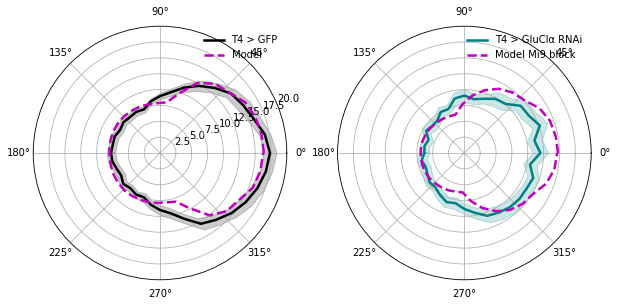

In [30]:
# Figure 5a:

displaySEM = True
rads = np.arange(-180,190,10) * np.pi/180

dd = [dvm_gfp, dvm_gluclarnai]
colors = ['k', 'teal']
labels = ['T4 > GFP', 'T4 > GluClα RNAi']

fig, ax = plt.subplots(1, 2, figsize=(10, 5), subplot_kw=dict(polar=True), sharey=True)   

# Plot data:
for idx, d in enumerate(dd):
    y = np.append(d.mean(0), d.mean(0)[0])
    sem = np.append(stats.sem(d), stats.sem(d)[0])
    ax[idx].plot(rads, y, color=colors[idx], linewidth=2.5, label=labels[idx])
    ax[idx].fill_between(rads, y-sem, y+sem, color=colors[idx], alpha=0.2)

# Run model:
gMi9, gTm3, gMi1, gMi4, gC3, T4model, tune_wt = dir_tuning()                        # full model
gMi9, gTm3, gMi1, gMi4, gC3, T4model, tune_mi9block = dir_tuning(onoff=[0,1,1,1,1]) # model without Mi9

# Plot model prediction:
ax[0].plot(tune_wt[0]* np.pi/180, tune_wt[1] , color='m', linestyle='--', linewidth=2.5, label='Model')
ax[1].plot(tune_mi9block[0]* np.pi/180, tune_mi9block[1] , color='m', linestyle='--', linewidth=2.5, label='Model Mi9 block')

for i in range(2):
    ax[i].set_ylim(0,20)
    ax[i].legend(frameon=False)
    
#plt.savefig('fig5a.pdf')

In [5]:
# Load exemplary traces:
vm_gfp = np.load('fig5b_vm_gfp.npy')
vm_gluclarnai = np.load('fig5b_vm_gluclarnai.npy')
vm_nmdar1rnai = np.load('fig5b_vm_nmdar1rnai.npy')

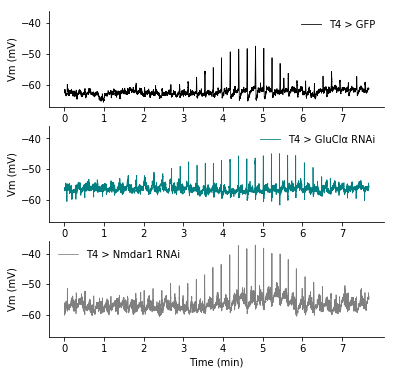

In [6]:
# Figure 5b:
fs = 100 # sampling frequency for plotting: 100 Hz

fig, ax = plt.subplots(3,1,figsize=(6,6), sharey=True)
time = np.arange(0, len(vm_gfp)/fs, 1/fs)
colours = ['k', 'teal', 'grey']
labels = ['T4 > GFP', 'T4 > GluClα RNAi', 'T4 > Nmdar1 RNAi']
for idx, i in enumerate([vm_gfp, vm_gluclarnai, vm_nmdar1rnai]):
    ax[idx].plot(time, i, c=colours[idx], linewidth=0.8, label=labels[idx])
    ax[idx].set_xticks(np.arange(0, 480, 60))
    ax[idx].set_xticklabels(np.arange(0,8,1))
    ax[idx].set_ylabel("Vm (mV)")
    ax[idx].legend(frameon=False)
ax[-1].set_xlabel("Time (min)");

#plt.savefig('fig5b.pdf')

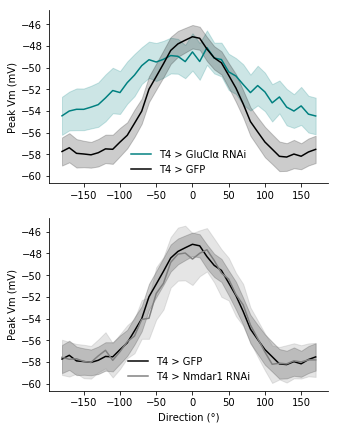

In [7]:
# Figure 5c:
# Load measured peak membrane potentials:
pvm_gfp = np.load('fig5c_pvm_gfp.npy')
pvm_gluclarnai = np.load('fig5c_pvm_gluclarnai.npy')
pvm_nmdar1rnai = np.load('fig5c_pvm_nmdar1rnai.npy')

# Figure 5c left:
dd = [pvm_gluclarnai, pvm_gfp, pvm_nmdar1rnai]
labels = ['T4 > GluClα RNAi', 'T4 > GFP', 'T4 > Nmdar1 RNAi']
colours = ['teal', 'k', 'grey']
fig, ax = plt.subplots(2,1, figsize=(5,7), sharey=True)

degs = np.arange(-180,180,10)

# GFP vs. GluClα RNAi:
for idx, d in enumerate(dd[0:2]):
    y = d.mean(0)
    sem = stats.sem(d, axis=0)
    ax[0].plot(degs, y, c=colours[idx], label=labels[idx])
    ax[0].fill_between(degs, y-sem, y+sem, color=colours[idx], alpha=0.2)
    ax[0].set_ylabel("Peak Vm (mV)")
    ax[0].legend(frameon=False)
    # GFP vs. Nmdar1 RNAi:
for idx, d in enumerate(dd[1:3]):
    y = d.mean(0)
    sem = stats.sem(d, axis=0)
    ax[1].plot(degs, y, c=colours[idx+1], label=labels[idx+1])
    ax[1].fill_between(degs, y-sem, y+sem, color=colours[idx+1], alpha=0.2)
    ax[1].set_ylabel("Peak Vm (mV)")
    ax[1].legend(frameon=False)
ax[1].set_xlabel("Direction (°)");
#plt.savefig('fig5c_left.pdf')

In [8]:
# Calculate Ldir (direction selectivity indices):
def get_ldirs(data):
    ldirs = np.full(data.shape[0], np.nan)
    for idx, d in enumerate(data):
        d_norm = normalize(d)
        n = d_norm.size
        angles = np.arange(n)*360/n*np.pi/180
       
        # calculate x- and y-coordinates
        x = d_norm * np.cos(angles)
        y = d_norm * np.sin(angles)
       
        res_vec_x = np.sum(x)
        res_vec_y = np.sum(y)
        res_vec_mag = np.sqrt(res_vec_x**2+res_vec_y**2)
        mag = np.abs(np.sum(d_norm))
        ldirs[idx]  = res_vec_mag/mag
     
    return ldirs

# Dictionary of Ldirs:
ldirs = {
        "GFP": [get_ldirs(pvm_gfp)],
        "GluClα RNAi": [get_ldirs(pvm_gluclarnai)],
        "Nmdar1 RNAi": [get_ldirs(pvm_nmdar1rnai)]
          }

# Turn dictionary into panas DataFrame:
def make_df(dic):
    ldir_df = pd.DataFrame()
    for genotype, cells in dic.items():
        for ldir in cells:
            df = pd.DataFrame()
            df['Ldir'] = ldir
            df['Genotype'] =  genotype
            ldir_df = ldir_df.append(df)
    return ldir_df


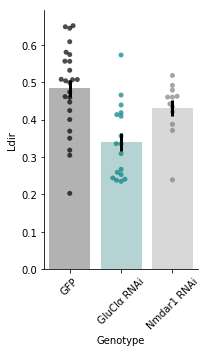

In [9]:
# Figure 5c right:
colours = ['k', 'teal', 'grey']
dotsize = 5

ldir_df = make_df(ldirs)

fig, ax = plt.subplots(1,1, figsize=(3, 5))
a = sns.swarmplot(x="Genotype", y="Ldir", hue="Genotype", palette=colours,
                  data=ldir_df, dodge=False, alpha=0.7, size=dotsize, ax=ax)
a.legend_.remove()
b = sns.barplot(x="Genotype", y="Ldir", hue="Genotype", palette=colours,
                data=ldir_df, dodge=False, ci=None, alpha=.3, ax=ax);
b.errorbar(x=np.arange(0, len(ldir_df.Genotype.unique())),y=ldir_df.groupby(['Genotype'], sort=False).mean().Ldir,
           yerr=ldir_df.groupby(['Genotype'], sort=False).sem().Ldir, fmt='none', c='k', zorder=3, 
           elinewidth=3)
b.legend_.remove()

ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
ax.set_ylabel('Ldir')

ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
ax.set_ylabel('Ldir')

sns.despine()
plt.tight_layout()
#plt.savefig('fig5c_right.pdf', rasterized=False)       
            

In [10]:
# Figure 5e-i and Extended Data Figure 10:
# Load data:
data1_R39H12_edges = pd.read_csv('fig5_R39H12_edges.csv')
data2_R39H12_barfixation = pd.read_csv('fig5_R39H12_barfixation.csv')

# Apply inclusion criteria:
def include_exclude(data, forward_min, min_trials, r_dev=None):
    """ Apply inclusion criteria to preprocessed dataset
    
        :data: pandas dataframe.
        :forward_min: the minimal average forward walking velocity (cm/s) for which a trial is included.
        :r_dev: the maximal average rotational velocity (degrees/s) over all included trials for which a fly is included (only used in fixation experiments).
        :min_trials: the minimal number of trials for which a fly is included.
        
        :returns: only the included trials and flies.
    """
    
    # Calculate mean forward speed per fly per trial
    d = data
    mean_forward = d.groupby(['flyname', 'trial']).forward.mean()
    d = d.merge(mean_forward, on=['flyname', 'trial'], suffixes=('', '_mean'))

    ###################### INCLUSION CRITERION (mean forward velocity) ######################
    fast_data = d.query("forward_mean >= @forward_min")
    
    curr_data = fast_data
    n_trials = curr_data.groupby(['flyname']).trial.unique().str.len()
    curr_data = curr_data.merge(n_trials, on='flyname', suffixes=('', 's_n'))
    s = curr_data
    
    mean_rotation = s.groupby(['flyname']).rotation.mean()
    s = s.merge(mean_rotation, on=['flyname'], suffixes=('', '_mean'))

    if r_dev != None:
        ######### INCLUSION CRITERION (average rotation deviation from 0 degree) ############
        straight_flies = s.query("rotation_mean <= (0 + @r_dev) and rotation_mean >= (0 - @r_dev)")
    else:
        straight_flies = s

    ##################### INCLUSION CRITERION (minimal number of trials) ####################
    included_data = straight_flies.query("trials_n >= @min_trials")

    data_included = included_data.drop(columns=['forward_mean', 'rotation_mean'])
    
    return data_included

data1_R39H12_edges_included = include_exclude(data = data1_R39H12_edges, forward_min = 0.15, min_trials = 10)
data2_R39H12_barfixation_included = include_exclude(data = data2_R39H12_barfixation, forward_min = 0.40, min_trials = 50, r_dev = 10)

In [11]:
# Sort datasets: 
def order_dataset(data, columns_to_keep, index_columns):
    """ Order dataset based on genotypes and remove unnecessary columns
    
    :data: dataset with all included flies and trials
    :columns_to_keep: list of all columns that should be kept
    :index_columns: list of all columns that should be used as index
    
    :return: ordered dataset
    """
    
    data = data.loc[:, columns_to_keep]
    genotype_list = {
        'R39H12': 1,
        'R59E08_R42F06': 2,
        'GluCla_RNAi': 3,
        'R39H12>GluCla_RNAi': 4,
        'R59E08_R42F06>GluCla_RNAi': 5,
        'NMDA_R1_RNAi': 6,
        'R39H12>NMDA_R1_RNAi': 7,
    }
    
    data.loc[:,'ordered_index'] = data['genotype'].map(genotype_list)
    indices = ['ordered_index'] + index_columns
    data_ordered = data.set_index(indices).sort_values(by=indices) 
    
    return data_ordered

# Sort data for Figure 5:
data1_R39H12_edges_ordered = order_dataset(data1_R39H12_edges_included, columns_to_keep = ['genotype', 'flyname', 'brighterdarker', 
                                        'edge_rotation_in_unitcircle_conventions', 'trial', 
                                        'time', 'forward', 'rotation', 'x', 'y'], index_columns = ['genotype', 'flyname', 
                                        'brighterdarker', 'edge_rotation_in_unitcircle_conventions', 
                                                                              'trial', 'time'])

data2_R39H12_barfixation_ordered = order_dataset(data2_R39H12_barfixation_included, columns_to_keep = ['genotype', 'flyname', 'trial', 
                                        'time', 'forward', 'rotation', 'bar_angle', 'trials_n'], index_columns = ['genotype', 'flyname', 
                                                                                         'trial', 'time'])


In [12]:
# Figure 5e,  f:
# Normalise rotation per trial: set mean rotation of every trial (16 edge directions) to 0
# Calculate mean rotation per fly per trial
temp = data1_R39H12_edges_ordered.reset_index()
rotation_mean = temp.groupby(['flyname', 'trial']).rotation.mean()
temp = temp.merge(rotation_mean, on=['flyname', 'trial'], suffixes=('', '_mean'))

# Recalculate rotation based on trial mean. 
data1_R39H12_edges_rotation_normalized = temp
data1_R39H12_edges_rotation_normalized.at[:,'rotation_normalized'] = data1_R39H12_edges_rotation_normalized.rotation - data1_R39H12_edges_rotation_normalized.rotation_mean
data1_R39H12_edges_rotation_normalized = data1_R39H12_edges_rotation_normalized.set_index(['ordered_index', 'genotype', 'flyname', 'brighterdarker', 'edge_rotation_in_unitcircle_conventions','trial', 'time']).drop(columns=['rotation_mean'])

# Average the fly's rotation over trials
data1_R39H12_edges_rotation_trial_averaged = data1_R39H12_edges_rotation_normalized.groupby(['ordered_index', 'genotype', 'flyname', 'brighterdarker', 'edge_rotation_in_unitcircle_conventions','time']).mean()
data1_R39H12_edges_rotation_trial_averaged.reset_index().groupby(["ordered_index", "genotype", "brighterdarker"]).apply(lambda df: len(df.flyname.unique()))

ordered_index  genotype             brighterdarker
1              R39H12               -1.0              25
                                     1.0              19
3              GluCla_RNAi          -1.0              23
                                     1.0              18
4              R39H12>GluCla_RNAi   -1.0              20
                                     1.0              20
6              NMDA_R1_RNAi         -1.0              20
                                     1.0              18
7              R39H12>NMDA_R1_RNAi  -1.0              20
                                     1.0              18
dtype: int64

In [13]:
# Average over trials (calculate mean rotation for each stimulus):
data1_R39H12_edges_rotation_stimulus_time = data1_R39H12_edges_rotation_trial_averaged.reset_index().query("0.5 <= time <= 5.5") # Stimulus duration
data1_R39H12_edges_rotation_averaged = data1_R39H12_edges_rotation_stimulus_time.reset_index().set_index([
    'ordered_index',
    'genotype',
    'brighterdarker',
    'flyname', 
    'edge_rotation_in_unitcircle_conventions']).groupby(level=[
    'ordered_index',
    'genotype',
    'brighterdarker',
    'flyname', 
    'edge_rotation_in_unitcircle_conventions']).apply(lambda g: pd.Series([g.rotation_normalized.mean()], 
                                                index=['mean_rotation']))
data1_R39H12_edges_vertical_tuning_plot = data1_R39H12_edges_rotation_averaged.reset_index()

edge_rotation_vertical_tuning_plot_transform = {
    0.0: 270.,
    22.5: 292.5,
    45.0: 315.,
    67.5: 337.5,
    90.0: 0.,
    112.5: 22.5,
    135: 45.,
    157.5: 67.5,
    180: 90.0,
    202.5: 112.5,
    225: 135.,
    247.5: 157.5,
    270: 180., 
    292.5: 202.5,
    315: 225,
    337.5: 247.5,
}

data1_R39H12_edges_vertical_tuning_plot.loc[:,'edge_rotation_vertical_tuning_plot'] = data1_R39H12_edges_vertical_tuning_plot['edge_rotation_in_unitcircle_conventions'].map(edge_rotation_vertical_tuning_plot_transform)

# Since we will be plotting circular data on an x-y graph, we avoid a empty space in the graph by copying the data belonging to 0-degrees edge rotation 
# to a new 360-degrees instance (0 and 360 degrees are the same stimulus, and will be plotted twice).
add360 = data1_R39H12_edges_vertical_tuning_plot.query("edge_rotation_vertical_tuning_plot == 0.0")
add360['edge_rotation_vertical_tuning_plot'] = 360.0
data1_R39H12_edges_vertical_tuning_plot = pd.concat([data1_R39H12_edges_vertical_tuning_plot, add360], axis=0)

/anaconda2/envs/PyClamp/lib/python3.7/site-packages/ipykernel_launcher.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [14]:
# Split dataset in ON and OFF data (these data are from separate flies):
data1_R39H12_ON_edges_vertical_tuning_plot = data1_R39H12_edges_vertical_tuning_plot.query("brighterdarker == 1")
data1_R39H12_OFF_edges_vertical_tuning_plot = data1_R39H12_edges_vertical_tuning_plot.query("brighterdarker == -1")

print("Rotated ON edges")
for gt in data1_R39H12_ON_edges_vertical_tuning_plot.genotype.unique():
    print(gt, "n =", len(data1_R39H12_ON_edges_vertical_tuning_plot.query("genotype == @gt").flyname.unique()))

print("\n")
print("Rotated OFF edges")
for gt in data1_R39H12_OFF_edges_vertical_tuning_plot.genotype.unique():
    print(gt, "n =", len(data1_R39H12_OFF_edges_vertical_tuning_plot.query("genotype == @gt").flyname.unique()))

Rotated ON edges
R39H12 n = 19
GluCla_RNAi n = 18
R39H12>GluCla_RNAi n = 20
NMDA_R1_RNAi n = 18
R39H12>NMDA_R1_RNAi n = 18


Rotated OFF edges
R39H12 n = 25
GluCla_RNAi n = 23
R39H12>GluCla_RNAi n = 20
NMDA_R1_RNAi n = 20
R39H12>NMDA_R1_RNAi n = 20


In [15]:
# Create DataFrames for plotting:
data1_R39H12_ON_edges_vertical_tuning_plot_mean = data1_R39H12_ON_edges_vertical_tuning_plot.groupby(['ordered_index','genotype', 'edge_rotation_in_unitcircle_conventions','edge_rotation_vertical_tuning_plot']).mean().reset_index() 
data1_R39H12_ON_edges_vertical_tuning_plot_mean = data1_R39H12_ON_edges_vertical_tuning_plot_mean.sort_values(by=['edge_rotation_vertical_tuning_plot', 'ordered_index', 'genotype'])

data1_R39H12_ON_edges_vertical_tuning_plot_sem = data1_R39H12_ON_edges_vertical_tuning_plot.groupby(['ordered_index', 'genotype', 'edge_rotation_in_unitcircle_conventions','edge_rotation_vertical_tuning_plot']).sem().reset_index()
data1_R39H12_ON_edges_vertical_tuning_plot_sem = data1_R39H12_ON_edges_vertical_tuning_plot_sem.sort_values(by=['edge_rotation_vertical_tuning_plot', 'ordered_index', 'genotype'])
data1_R39H12_ON_edges_vertical_tuning_plot_sem = data1_R39H12_ON_edges_vertical_tuning_plot_sem.rename(columns={'mean_rotation':'SEM'})

data1_R39H12_OFF_edges_vertical_tuning_plot_mean = data1_R39H12_OFF_edges_vertical_tuning_plot.groupby(['ordered_index', 'genotype', 'edge_rotation_in_unitcircle_conventions','edge_rotation_vertical_tuning_plot']).mean().reset_index() 
data1_R39H12_OFF_edges_vertical_tuning_plot_mean = data1_R39H12_OFF_edges_vertical_tuning_plot_mean.sort_values(by=['edge_rotation_vertical_tuning_plot', 'ordered_index', 'genotype'])

data1_R39H12_OFF_edges_vertical_tuning_plot_sem = data1_R39H12_OFF_edges_vertical_tuning_plot.groupby(['ordered_index', 'genotype', 'edge_rotation_in_unitcircle_conventions','edge_rotation_vertical_tuning_plot']).sem().reset_index()
data1_R39H12_OFF_edges_vertical_tuning_plot_sem = data1_R39H12_OFF_edges_vertical_tuning_plot_sem.sort_values(by=['edge_rotation_vertical_tuning_plot', 'ordered_index', 'genotype'])
data1_R39H12_OFF_edges_vertical_tuning_plot_sem = data1_R39H12_OFF_edges_vertical_tuning_plot_sem.rename(columns={'mean_rotation':'SEM'})

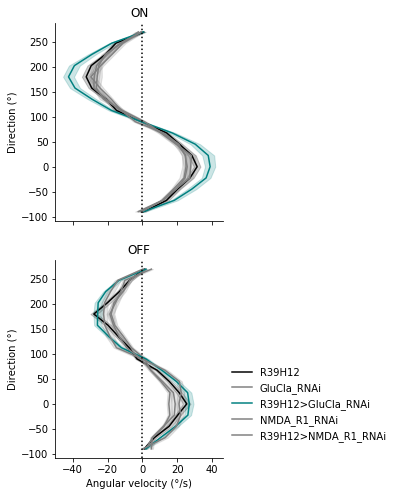

In [16]:
# Figure 5f top:
fig, ax = plt.subplots(2,1, figsize=(3,8), sharex=True, sharey=True)

genotypes = ['R39H12', 'GluCla_RNAi', 'R39H12>GluCla_RNAi', 'NMDA_R1_RNAi', 'R39H12>NMDA_R1_RNAi']
colors = ['k', 'grey', 'teal', 'grey', 'grey']

data = [data1_R39H12_ON_edges_vertical_tuning_plot_mean, data1_R39H12_OFF_edges_vertical_tuning_plot_mean]
error = [data1_R39H12_ON_edges_vertical_tuning_plot_sem, data1_R39H12_OFF_edges_vertical_tuning_plot_sem]

for idxd, d in enumerate(data):
    for idx, gt in enumerate(genotypes):
        x = data[idxd].query("genotype == @gt").mean_rotation*-1
        y = data[idxd].query("genotype == @gt").edge_rotation_vertical_tuning_plot-90
        err = error[idxd].query("genotype == @gt").SEM
        ax[idxd].plot(x, y, color=colors[idx], label=genotypes[idx])
        ax[idxd].fill_betweenx(y, x-err, x+err, color=colors[idx], alpha=0.2)
    ax[idxd].axvline(0, linestyle=':', color='k')
ax[1].set_xlabel('Angular velocity (°/s)')
for i in range(2):
    ax[i].set_ylabel('Direction (°)')
sns.despine()

ax[0].set_title('ON')
ax[1].set_title('OFF')
plt.legend(frameon=False, bbox_to_anchor=(1.0, 0.5));
#plt.savefig('fig5f.pdf');

In [17]:
# Quantification:
data1_R39H12_ON_edges_quantification = data1_R39H12_edges_rotation_averaged.query("brighterdarker == 1").reset_index()
data1_R39H12_OFF_edges_quantification = data1_R39H12_edges_rotation_averaged.query("brighterdarker == -1").reset_index()

def quantify_edge_experiment(data):
    # Calculate the horizontal component present in each stimulus, in a range between -1 (only leftward movement) and 1 (only rightward movement). 0 means up or downward movmement
    data_horizontal_components = data.assign(stimulus_horizontal_component = lambda x: round(np.cos(data['edge_rotation_in_unitcircle_conventions']/180 * np.pi), 5)).drop(columns = ['edge_rotation_in_unitcircle_conventions', 'brighterdarker'])
    
    # Calculate the mean rotation of the fly into the direction of the stimulus. Negative rotation values (leftwards rotation) to leftwards edge movement become positive.
    data_horizontal_components["mean_rotation_in_stim_dir"] = data_horizontal_components["mean_rotation"] * data_horizontal_components["stimulus_horizontal_component"] / abs(data_horizontal_components["stimulus_horizontal_component"])
   
    # replace NaN in mean_rotation_in_stim_dir with mean_rotation for the stimuli where the horizontal component is zero (only upwards or downwards motion) 
    data_horizontal_components["mean_rotation_in_stim_dir"] = data_horizontal_components["mean_rotation_in_stim_dir"].mask(pd.isnull, data_horizontal_components["mean_rotation"])
   
    # All horizontal components can be made positive, since the mean_rotation_in_stim_dir does not depend on the stimulus direction anymore
    data_horizontal_components["abs_stimulus_horizontal_component"] = abs(data_horizontal_components["stimulus_horizontal_component"])

    data_rotation_in_stimulus_direction_mean = data_horizontal_components.groupby(['flyname','abs_stimulus_horizontal_component']).mean_rotation_in_stim_dir.mean()
    data_rotation_in_stimulus_direction = data_horizontal_components.merge(data_rotation_in_stimulus_direction_mean, on=['flyname', 'abs_stimulus_horizontal_component'], suffixes = ('', '_mean'))
    data_rotation_in_stimulus_direction_plotting = data_rotation_in_stimulus_direction.loc[:,['ordered_index', 'genotype', 'flyname', 'abs_stimulus_horizontal_component', 'mean_rotation_in_stim_dir_mean']].drop_duplicates()
    
    return data_rotation_in_stimulus_direction_plotting

data1_R39H12_ON_edges_plotting = quantify_edge_experiment(data1_R39H12_ON_edges_quantification)
data1_R39H12_OFF_edges_plotting = quantify_edge_experiment(data1_R39H12_OFF_edges_quantification)

def calculate_regression_slopes(data):
    data_regressions = data.groupby(['ordered_index','genotype','flyname'], as_index=False).agg({
    'abs_stimulus_horizontal_component':list, 'mean_rotation_in_stim_dir_mean': list})
    
    slope_values = pd.DataFrame(columns=['flyname', 'slope_value'])

    for i, fly in enumerate(data_regressions.flyname):
        slope_value = stats.linregress(x = data_regressions.loc[i, 'abs_stimulus_horizontal_component'][:], y = data_regressions.loc[i, 'mean_rotation_in_stim_dir_mean'][:])[0]
        temp = pd.DataFrame([[fly, slope_value]], columns=(['flyname', 'slope_value']))
        slope_values = slope_values.append(temp, ignore_index=True)
    slope_values

    data_regressions_slopes = data_regressions.merge(slope_values, on=['flyname'])
    
    return data_regressions_slopes

data1_R39H12_ON_edges_plotting_slopes = calculate_regression_slopes(data1_R39H12_ON_edges_plotting)
data1_R39H12_OFF_edges_plotting_slopes = calculate_regression_slopes(data1_R39H12_OFF_edges_plotting)

data1_R39H12_ON_edges_statistics_turningspeed = data1_R39H12_ON_edges_plotting_slopes.drop(columns=['ordered_index', 'abs_stimulus_horizontal_component', 'mean_rotation_in_stim_dir_mean']).rename(columns={'slope_value':'turning_speed'})
data1_R39H12_OFF_edges_statistics_turningspeed = data1_R39H12_OFF_edges_plotting_slopes.drop(columns=['ordered_index', 'abs_stimulus_horizontal_component', 'mean_rotation_in_stim_dir_mean']).rename(columns={'slope_value':'turning_speed'})


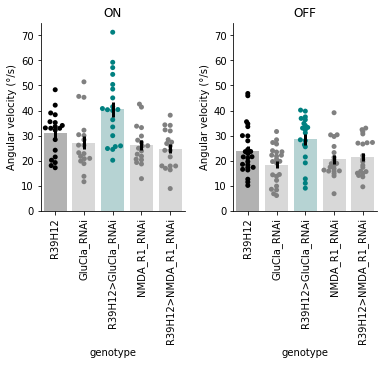

In [18]:
# Figure 5f top:
behavior = [data1_R39H12_ON_edges_statistics_turningspeed, data1_R39H12_OFF_edges_statistics_turningspeed]

dotsize = 5

fig, ax = plt.subplots(1,2,figsize=(5.5,5))
bpal = ['k', 'gray', 'teal', 'gray', 'gray']

for idx, d in enumerate(behavior):
    a = sns.swarmplot(x="genotype", y="turning_speed", hue="genotype", palette=bpal,
                  data=d, dodge=False, alpha=1.0, ax=ax[idx], size=dotsize)
    a.legend_.remove()
    b = sns.barplot(x="genotype", y="turning_speed", hue="genotype", palette=bpal,
                data=d, dodge=False, ci=None, alpha=.3, ax=ax[idx])
    b.errorbar(x=np.arange(0, len(d.genotype.unique())),y=d.groupby(['genotype'], sort=False).mean().turning_speed,
             yerr=d.groupby(['genotype'], sort=False).sem().turning_speed, fmt='none', c='k', zorder=3, elinewidth=3)
    b.legend_.remove()
    a.set_ylim(0,75)
    
for i in range(len(ax)):
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation = 90)
sns.despine()
plt.tight_layout()

ax[0].set_title('ON')
ax[1].set_title('OFF')
ax[0].set_ylabel('Angular velocity (°/s)')
ax[1].set_ylabel('Angular velocity (°/s)');

#plt.savefig('fig5f.pdf');

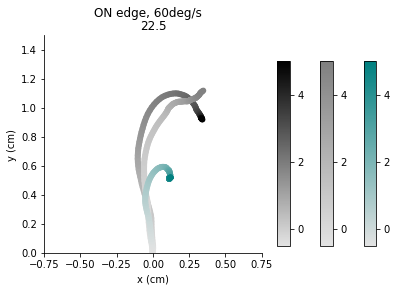

In [19]:
# Figure 5e (average walking trajectories):
data1_R39H12_edges_path_plotting = data1_R39H12_edges_rotation_trial_averaged.groupby(['ordered_index', 'genotype', 'brighterdarker', 'edge_rotation_in_unitcircle_conventions', 'time']).mean()
data1_R39H12_edges_path_plotting = data1_R39H12_edges_path_plotting.reset_index().query("0.0 <= time <= 5.5 and brighterdarker == 1.0").set_index(['ordered_index', 'genotype', 'brighterdarker', 'edge_rotation_in_unitcircle_conventions'])
stim = 22.5  # Edge is rotated 22.5 degrees

cmaps = {
    'R39H12': mpl.colors.LinearSegmentedColormap.from_list('colormap_R39H12', ['#e3e3e3', '#000000'], N=256),
    'GluCla_RNAi': mpl.colors.LinearSegmentedColormap.from_list('colormap_GluCla_RNAi', ['#e3e3e3', 'grey'], N=256),
    'R39H12>GluCla_RNAi': mpl.colors.LinearSegmentedColormap.from_list('colormap_R39H12>GluCla_RNAi', ['#e3e3e3', 'teal'], N=256),
}
 
genotypes = ['R39H12', 'GluCla_RNAi', 'R39H12>GluCla_RNAi']

fig, ax = plt.subplots()
for gidx, gt in enumerate(genotypes):
    
    ds = data1_R39H12_edges_path_plotting.xs(gt, level='genotype').xs(stim, level='edge_rotation_in_unitcircle_conventions')
             
    x = ds.x
    y = ds.y
    t_stim = ds.time
       
    # Create a set of line segments so that we can color them individually
    # This creates the points as a N x 1 x 2 array so that we can stack points
    # together easily to get the segments. The segments array for line collection
    # needs to be (numlines) x (points per line) x 2 (for x and y)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
       
    # Create a continuous norm to map from data points to colors
    norm = plt.Normalize(t_stim.min(), t_stim.max())
    cmap_ = cmaps[gt]
    lc = LineCollection(segments, cmap=cmap_, norm=norm)
       
    # Set the values used for colormapping
    lc.set_array(t_stim)
    lc.set_linewidth(6)
    lc.set_capstyle('round')
    line = ax.add_collection(lc)
 
    ax.set_xlim(-0.75, 0.75)
    ax.set_ylim(0, 1.5)
 
    ax.set(adjustable='box', aspect='equal')
       
    sns.despine(ax=ax)
    ax.set_title(format(stim))
       
    ax.set_ylabel("y (cm)")
    ax.set_xlabel("x (cm)")
    
    cbar_ax = fig.add_axes([0.8+gidx/10, 0.15, 0.03, 0.64])
    fig.colorbar(line, cax=cbar_ax, ticks=[0.5, 2.5, 4.5])
    cbar_ax.set_yticklabels([0, 2, 4])

plt.suptitle('ON edge, 60deg/s');
#plt.savefig('fig53.pdf')

In [20]:
# Figure 5h:
# (Closed-loop bar fixation experiment, with T4/T5 R39H12-Gal4, UAS-GluCla_RNAi, UAS-NMDA_R1_RNAi.)

data2_R39H12_barfixation_ordered

print("Bar fixation R39H12")
for gt in data2_R39H12_barfixation_ordered.reset_index().genotype.unique():
    print(gt, "n =", len(data2_R39H12_barfixation_ordered.reset_index().query("genotype == @gt").flyname.unique()))

Bar fixation R39H12
R39H12 n = 16
GluCla_RNAi n = 18
R39H12>GluCla_RNAi n = 21
NMDA_R1_RNAi n = 14
R39H12>NMDA_R1_RNAi n = 8


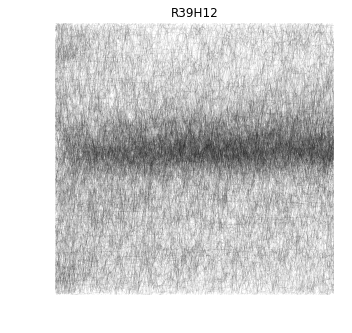

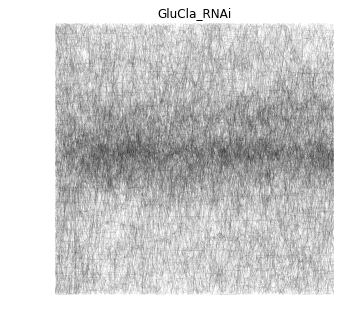

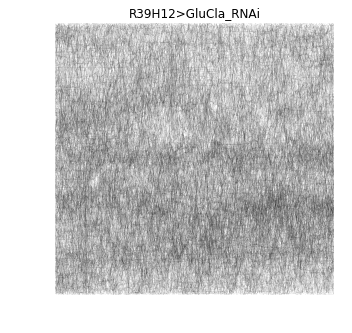

In [21]:
# Plot example traces of bar angle:
def get_min_fly_n(data):
    """
    Calculate the minimal number of flies belonging to a unique genotype in the dataset.
    """
    df = data.reset_index()
    n_flies = []
    for gt in df.genotype.unique():
        n_flies.append(len(df.query("genotype == @gt").flyname.unique()))
    return np.min(n_flies)

def plot_bar_angle_traces(data, genotype, show_labels, path_name, alpha):
    """
    Plot and save the trajectory traces of the bar angle over time.
    data: dataset with all genotypes that need to be plotted.
    genotype: string, the genotype to plot currently.
    show_labels: boolean, whether to show axis labels.
    path_name: string, indicate where the plot needs to be saved. 
    """
    min_fly_n = get_min_fly_n(data)
    min_trial_n = data.reset_index().trials_n.min()
    
    flies = list(data.reset_index().query("genotype == @genotype").flyname.unique()[:min_fly_n])

    ds = data.query("genotype == @genotype and trial <= @min_trial_n and flyname == @flies").reset_index()

    x = ds.time
    y = ds.bar_angle

    # Create a set of line segments so that we can plot them individually
    # This creates the points as a N x 1 x 2 array so that we can stack points
    # together easily to get the segments. The segments array for line collection
    # needs to be (numlines) x (points per line) x 2 (for x and y)

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([points[:-1], points[1:]], axis=1)

    # Mask the line elements that cross vertically. The bar crosses the midline behind the fly here (the 180-degree / -180-degree border)
    mask = np.full_like(segs, 0, dtype=bool)

    for i in range(len(segs)):
        if (abs(segs[i,0,1] - segs[i,1,1]) > 180):
            mask[i,:,:] = [[True, True], [True, True]]

        # when the two time values of a segment are not 0.05s apart, this means the new values are from a new trial or fly. The connecting horizontal line should also not be drawn.
        if (abs(segs[i,0,0] - segs[i,1,0]) > 5):
            mask[i,:,:] = [[True, True], [True, True]]

    segs = np.ma.masked_where((mask), segs)

    fig, ax = plt.subplots(figsize=(5,5))

    ax.set_xlim(0, 20)
    ax.set_ylim(-180, 180)
    ax.set_yticks([-180, -90, 0, 90, 180])

    line_segments = LineCollection(segs, linewidth=0.5, color="k", alpha = alpha)

    ax.add_collection(line_segments)
    
    ax.set_title(genotype)
    ax.set_ylabel('Bar position (°)')
    ax.set_xlabel('Time (s)')
    
    if show_labels == False:
        plt.axis('off')
    
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    
    #plt.savefig(path_name, bbox_inches=extent)
    
    return

data2_R39H12_barfixation_tracesplot = data2_R39H12_barfixation_ordered.query("genotype != ['NMDA_R1_RNAi','R39H12>NMDA_R1_RNAi']")

plot_bar_angle_traces(data=data2_R39H12_barfixation_tracesplot, genotype='R39H12', show_labels=False, path_name='fig5h_traces_R39H12.png', alpha=0.1)
plot_bar_angle_traces(data=data2_R39H12_barfixation_tracesplot, genotype='GluCla_RNAi', show_labels=False, path_name='fig5h_traces_GluCla_RNAi.png', alpha=0.1)
plot_bar_angle_traces(data=data2_R39H12_barfixation_tracesplot, genotype='R39H12>GluCla_RNAi', show_labels=False, path_name='fig5h_traces_R39H12>GluCla_RNAi.png', alpha=0.1)

In [22]:
# Analysis fo Figure 5h, bottom (probability densities):
# Aggregate all bar_angle values of each trial in a list. Every list contains 400 values, because each trial is 20s long,
# and the measurements are taken every 0.05s:

data2_R39H12_barfixation_densityplots = data2_R39H12_barfixation_ordered.groupby(['ordered_index','genotype','flyname', 'trial', 'trials_n']).agg({'bar_angle':list})
data2_R39H12_barfixation_densityplots = data2_R39H12_barfixation_densityplots.reset_index()

# Divide the bar_angle range [-180 to  +180 degrees] into 72 bins spanning 5 degrees each, and count for every trial how many measurements
# fall within each bin. The total hist_count for each trial will sum to the 400 measurements which make up each trial.
def bar_angle_histogram_counts(data, measurement_range_min, measurement_range_max, bins):  
    """
    Count the number of values per value that fall in each defined histogram bin.
    data: dataset
    measurement_range_min: minimal value of the measurement range (will be lower bound of histogram).
    measurement_range_max: maximal value of the measurement range (will be upper bound of histogram).
    bins: number of bins to divide the measurement_range in. 
    """
    hist_counts = pd.DataFrame(columns=['ordered_index', 'genotype', 'flyname', 'trial', 'hist_counts'])

    for i, fly in enumerate(data.flyname):
        hist_count = np.histogram(data.loc[i, 'bar_angle'][:], range = (measurement_range_min, measurement_range_max), bins = bins)[0]
        trial = data.loc[i, 'trial']
        genotype = data.loc[i, 'genotype']
        ordered_index = data.loc[i, 'ordered_index']
        temp = pd.DataFrame([[ordered_index, genotype, fly, trial, hist_count]], columns=(['ordered_index', 'genotype', 'flyname', 'trial', 'hist_counts']))
        hist_counts = hist_counts.append(temp, ignore_index=True)
    return hist_counts

data2_R39H12_barfixation_hist_counts = bar_angle_histogram_counts(data2_R39H12_barfixation_densityplots, -180, 180, 72)

In [23]:
def expand_hist_counts(data, measurement_range_min, measurement_range_max, bins):
    """
    data: dataset
    measurement_range_min: minimal value of the measurement range (will be lower bound of histogram).
    measurement_range_max: maximal value of the measurement range (will be upper bound of histogram).
    bins: number of bins to divide the measurement_range in. 
    
    Give the same values as used in the bar_angle_histogram_counts function.
    """
    
    hist_counts_flyagg = data.set_index(['ordered_index', 'genotype', 'flyname', 'trial'])
    hist_counts_flyagg = hist_counts_flyagg.groupby(['ordered_index', 'genotype', 'flyname']).agg({'hist_counts':list})
    hist_counts_flyagg = hist_counts_flyagg.reset_index()

    mean_bin_counts = pd.DataFrame(columns = (['ordered_index', 'genotype', 'flyname', 'mean_bin_count']))

    for i, fly in enumerate(hist_counts_flyagg.flyname):
        flydata = hist_counts_flyagg.loc[i, 'hist_counts']
        mean_bin_count = [float(sum(col))/len(col) for col in zip(*flydata)] # average over trials (rows) for all bins (columns).
        ordered_index = hist_counts_flyagg.loc[i, 'ordered_index']
        genotype = hist_counts_flyagg.loc[i, 'genotype']
        temp = pd.DataFrame([[ordered_index, genotype, fly, mean_bin_count]], columns=(['ordered_index', 'genotype', 'flyname', 'mean_bin_count']))
        mean_bin_counts = mean_bin_counts.append(temp, ignore_index=True)
    mean_bin_counts
    
    bin_size = (measurement_range_max - measurement_range_min) / bins
    
    mean_bin_counts_long = mean_bin_counts.explode('mean_bin_count')
    bin_midpoint_ = [*np.arange((measurement_range_min + 0.5 * bin_size), (measurement_range_max + 0.5 * bin_size), bin_size)] # midpoint values of all bins
    mean_bin_counts_long['bin_midpoint'] = np.resize(bin_midpoint_,len(mean_bin_counts_long))
    mean_bin_counts_long.mean_bin_count = mean_bin_counts_long.mean_bin_count.astype(float)
    mean_bin_counts_long.bin_midpoint = mean_bin_counts_long.bin_midpoint.astype(float)
    
    return mean_bin_counts_long

data2_R39H12_barfixation_hist_counts_expanded = expand_hist_counts(data2_R39H12_barfixation_hist_counts, -180, 180, 72)

In [24]:
# To go from counts per 5°-bin to probability densities in % per °, we devide the values by 20. Since 400 values per trial
# divided by 4 gives percentages for each 5°-bin, and dividing by 5 gives the values per °:
data2_R39H12_barfixation_hist_densities = data2_R39H12_barfixation_hist_counts_expanded
data2_R39H12_barfixation_hist_densities.mean_bin_count = data2_R39H12_barfixation_hist_densities.mean_bin_count / 20
data2_R39H12_barfixation_hist_densities = data2_R39H12_barfixation_hist_densities.rename(columns={'mean_bin_count': 'probability_density'})

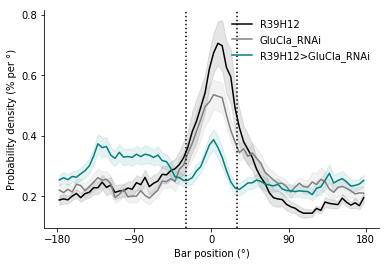

In [25]:
# Figure 5h, bottom (probability densities):
def plot_density(data, genotypes, colors, path_name):
    """
    Plot and save the density values of the bar angle for each genotype of interest.
    data: dataset with all genotypes that need to be plotted.
    genotypes: list of strings, the genotypes to plot.
    colors: list of strings corresponding to the colors for each genotype.
    path_name: string, indicate where the plot needs to be saved. 
    """
    data_mean = data.groupby(['genotype', 'bin_midpoint']).mean().reset_index() 
    data_sem = data.groupby(['genotype', 'bin_midpoint']).sem().reset_index()
    
    fig, ax = plt.subplots(1,1)

    for idx, gt in enumerate(genotypes):
        x = data_mean.query("genotype == @gt").bin_midpoint
        y = data_mean.query("genotype == @gt").probability_density
        err = data_sem.query("genotype == @gt").probability_density
        ax.plot(x, y, color=colors[idx], label=genotypes[idx])
        ax.fill_between(x, y-err, y+err, color=colors[idx], alpha=0.1)
    ax.set_ylabel('Probability density (% per °)')
    ax.set_xlabel('Bar position (°)')
    sns.despine()
    ax.axvline(-30, linestyle=':', color='k')
    ax.axvline(30, linestyle=':', color='k')
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])

    plt.legend(frameon=False);
    #plt.savefig(path_name)
    
plot_density(data2_R39H12_barfixation_hist_densities, genotypes = ['R39H12', 'GluCla_RNAi', 'R39H12>GluCla_RNAi'],
             colors = ['k', 'grey', 'teal'], path_name = 'fig5h_bottom.pdf')

In [26]:
# Analysis for Figure 5i:
# Calculate the probability of finding the bar in the 60°-frontal window for each trial seperately,
# and then average over flies and genotypes.

def fixation_in_front(data, measurement_range_min, measurement_range_max, bins):
    """
    data: dataset
    measurement_range_min: minimal value of the measurement range (will be lower bound of histogram).
    measurement_range_max: maximal value of the measurement range (will be upper bound of histogram).
    bins: number of bins to divide the measurement_range in. 
    
    Give the same values as used in the bar_angle_histogram_counts function.
    """
    
    bin_size = (measurement_range_max - measurement_range_min) / bins
    bin_midpoint_ = [*np.arange((measurement_range_min + 0.5 * bin_size), (measurement_range_max + 0.5 * bin_size), bin_size)] # midpoint values of all bins
    
    hist_counts_per_trial_long = data.explode('hist_counts')
    hist_counts_per_trial_long['bin_midpoint'] = np.resize(bin_midpoint_,len(hist_counts_per_trial_long))
    hist_counts_per_trial_long.hist_counts = hist_counts_per_trial_long.hist_counts.astype(float)
    hist_counts_per_trial_long.bin_midpoint = hist_counts_per_trial_long.bin_midpoint.astype(float)
    
    prob_density = hist_counts_per_trial_long.query("bin_midpoint in [-27.5, -22.5, -17.5, -12.5, -7.5, -2.5, 2.5, 7.5, 12.5, 17.5, 22.5, 27.5]")

    # divide hist_counts by 400 to make all values of one trial add up to 1 instead of 400.
    prob_density['prob_per_bin'] = prob_density.hist_counts / 400 

    fixation_in_front = pd.DataFrame(prob_density.groupby(['ordered_index','genotype','flyname', 'trial']).prob_per_bin.sum())
    fixation_in_front = fixation_in_front.rename({"prob_per_bin":"fixation_in_front"}, axis = 1)
    fixation_in_front_flymeans = pd.DataFrame(fixation_in_front.reset_index().groupby(['ordered_index','genotype','flyname']).fixation_in_front.mean())
    fixation_in_front_plotting = fixation_in_front_flymeans.reset_index()
    
    fixation_in_front_plotting["percent"] = fixation_in_front_plotting.fixation_in_front * 100
    
    return fixation_in_front_plotting

data2_R39H12_barfixation_fixation_in_front = fixation_in_front(data2_R39H12_barfixation_hist_counts, -180, 180, 72)

/anaconda2/envs/PyClamp/lib/python3.7/site-packages/ipykernel_launcher.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


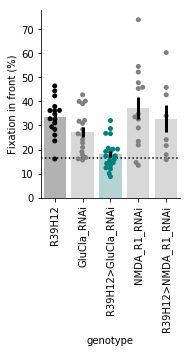

In [27]:
# Figure 5i:
bpal = ['k', 'gray', 'teal', 'gray', 'gray']
dotsize = 5

fig, ax = plt.subplots(1, 1, figsize=(2.75, 5))
a = sns.swarmplot(x="genotype", y="percent", hue="genotype", palette=bpal,
                  data=data2_R39H12_barfixation_fixation_in_front, dodge=False, alpha=1.0, size=dotsize)
a.legend_.remove()
a.axhline(16.6667, color = 'k', linestyle=':')
b = sns.barplot(x="genotype", y="percent", hue="genotype", palette=bpal,
                data=data2_R39H12_barfixation_fixation_in_front, dodge=False, ci=None, alpha=.3);
b.errorbar(x=np.arange(0, len(data2_R39H12_barfixation_fixation_in_front.genotype.unique())),y=data2_R39H12_barfixation_fixation_in_front.groupby(['genotype'], sort=False).mean().percent,
             yerr=data2_R39H12_barfixation_fixation_in_front.groupby(['genotype'], sort=False).sem().percent, fmt='none', c='k', zorder=3, elinewidth=3)
b.legend_.remove()

ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
ax.set_ylabel('Fixation in front (%)')

sns.despine()
plt.tight_layout()
#plt.savefig('fig5i.pdf');
